# Algorytm przecinania się odcinków na płaszczyźnie

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from bitalg.tests.test4 import Test
from bitalg.visualizer.main import Visualizer
from bitalg.sortedcontainers import SortedSet

# Przydatne funkcje 

In [2]:
def draw_example_1():
    vis=Visualizer()
    line_segments=((-0.5,0.5),(8.5,3.5),(1,3),(7,5),(2,4),(5,1),(4.5,3),(6.5,6),(0,5),(5.5,5.5))
    vis.add_line_segment(line_segments)
    vis.add_point([(x,y) for (x,y) in line_segments],s=25)
    vis.show()
    
def draw_example_2():
    vis=Visualizer()
    line_segments=((-0.5,0.5),(8.5,3.5),(1,3),(7,5),(2,4),(5,1),(4.5,3),(6.5,6),(0,5),(5.5,5.5))
    points=[(4,2),(2.5,3.5),(5.5,4.5)]
    vis.add_line_segment(line_segments)
    vis.add_point(points,color='red',s=35)
    vis.add_point([(x,y) for (x,y) in line_segments],s=25)
    vis.show()

### Wprowadzenie
Celem ćwiczenia jest zapoznanie się z algorytmem zamiatania wyznaczającym przecięcia się odcinków na płaszczyźnie oraz jego implementacja.

---
Algorytm zamiatania w przypadku powyższego problemu polega na tym, że ustalamy miotłę, którą będzie prosta równoległa do osi $y$. Przesuwamy miotłę w wyznaczonym kierunku (kierunku zamiatania), w tym przypadku w prawo (w kierunku rosnących współrzędnych x-owych). Odpowiednie pozycje x-owe, w których miotła zatrzymuje się, nazywamy zdarzeniami. Informacje o nich przechowujemy w strukturze zdarzeń. Z kolei informacje potrzebne do obliczeń przechowujemy w strukturze stanu. Struktura stanu jest aktualizowana w każdym zdarzeniu. Na „zamiecionym” obszarze (czyli na lewo od miotły) znane jest rozwiązanie badanego problemu dla zdarzeń należących do tego obszaru, natomiast przecięcia na prawo od miotły są nieznane. 

W każdym położeniu miotły wyróżniamy odcinki:
- przetworzone – oba ich końce znajdują się na lewo od miotły 
- aktywne – aktualnie przecinają miotłę 
- oczekujące – o obu końcach na prawo od miotły

Punktami zdarzeń są końce odcinków oraz punkty przecięć. Tutaj następuje aktualizacja stanu miotły (zbioru odcinków aktywnych - przecinających ją) oraz testy przecięć.

---
### Przykładowy zbiór odcinków przed wyznaczeniem punktów przecięcia

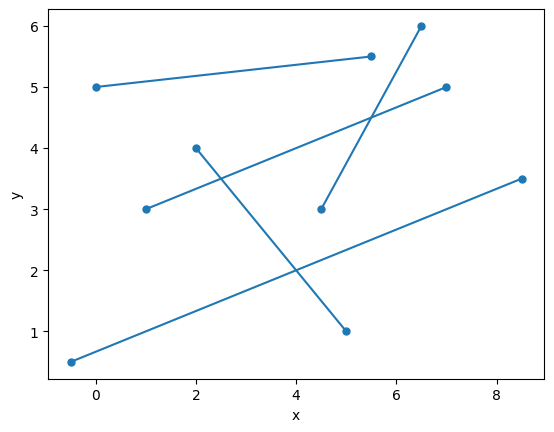

In [3]:
draw_example_1()

### Przykładowy zbiór odcinków po wyznaczeniu punktów przecięcia

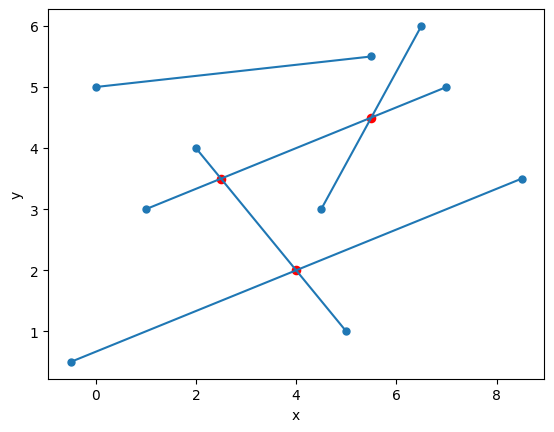

In [4]:
draw_example_2()

# Generowanie losowych odcinków na płaszczyźnie

<span style="color:red">Ćw.</span> Uzupełnij funkcję ```generate_uniform_sections```.

In [5]:
def generate_uniform_sections(max_x,max_y,n):
    """
    Funkcja generuje odcinki o współrzędnych rzeczywistych w postaci par punktów. 
    Żaden wygenerowany odcinek nie jest odcinkiem pionowym.
    Żadne dwa odcinki nie mają swoich końców o takiej samej współrzędnej x.
    Zakres współrzędnych: dla x - (0, max_x), dla y - (0, max_y).
    Pierwszy punkt reprezentujący odcinek to punkt "lewy" - o mniejszej współrzędnej x, drugi punkt to "prawy"
    :param max_x: określa maksymalną wartość współrzędnej x, jaka może zostać wylosowana
    :param max_y: określa maksymalną wartość współrzędnej y, jaka może zostać wylosowana
    :param n: ilość generowanych odcinków
    :return: tablica długości n odcinków w postaci krotek zawierających parę krotek 
    współrzędnych końców odcinków np. [((x1, y1), (x2, y2)), ((x3, y3), (x4, y4)),...]
    """
    result = []
    all_x = set()
    while (len(result) < n):
        start_x, start_y, end_x, end_y = 0,0,0,0
        while(True):
            start_x = np.random.uniform(high = max_x)
            if not all_x.issuperset({start_x}):
                all_x.add(start_x)
                break

        while(True):
            end_x = np.random.uniform(low = start_x, high = max_x)
            if not all_x.issuperset({end_x}):
                all_x.add(end_x)
                break
        
        start_y = np.random.uniform(high = max_y)
        end_y = np.random.uniform(high = max_y)
        result.append(((start_x, start_y), (end_x, end_y)))
    return result

Przetestuj działanie funkcji ```generate_uniform_sections```.

In [6]:
Test().runtest(1,generate_uniform_sections)

Lab 4, task 1:
	Test 1: Passed
	Test 2: Passed
	Test 3: Passed
Result: 3/3
Time: 0.052s


<span style="color:red">Ćw.</span> Wygeneruj 20 losowych odcinków w przestrzeni 2D o współrzędnych z przedziału $\langle 0,1000\rangle$. 

In [7]:
generated_sections=generate_uniform_sections(1000,1000,20)

Zwizualizuj otrzymane odcinki.

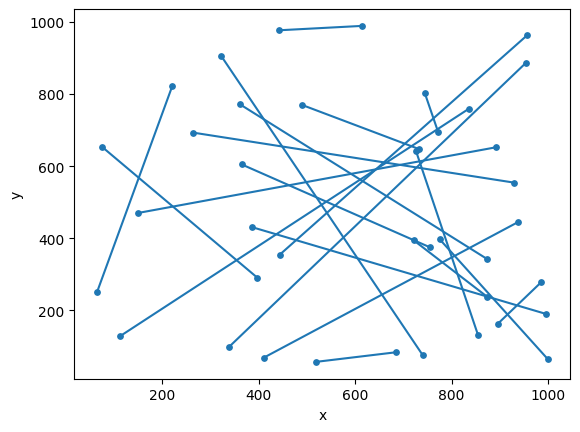

In [8]:
vis=Visualizer()
vis.add_line_segment(generated_sections)
vis.add_point([generated_sections[i//2][i%2] for i in range(2*len(generated_sections))],s=15)
vis.show()

<span style="color:red">Ćw.</span> Zaimplementuj możliwość interaktywnego dodawania odcinków przez rysowanie myszką.

In [9]:
class Point:
    def __init__(self,x,y):
        self.x=x 
        self.y=y 
        
    def __eq__(self,other): 
        return self.x==other.x and self.y==other.y
    
    def __gt__(self,other): 
        return self.x>other.x

    def __lt__(self,other):
        return self.x<other.x    
    
    def __hash__(self):
        return hash((self.x,self.y))
    
class Section:
    x = 0 #stan miotły, ułatwia porównywanie odcinków
    def __init__(self,L,R):
        self.L=L 
        self.R=R 

        #postać kierunkowa
        self.a=(self.L.y-self.R.y)/(self.L.x-self.R.x) 
        self.b=self.L.y-self.a*self.L.x 
        

    @staticmethod
    def update_sweep(x): 
        Section.x=x    
        
    def __eq__(self,other):
        return (self.L==other.L and self.R==other.R)
    
    def __gt__(self,other):
        return self.a * Section.x + self.b > other.a * Section.x + other.b

    def __lt__(self, other):
        return self.a * Section.x + self.b < other.a * Section.x + other.b     
    
    def __hash__(self):
        return hash((self.L,self.R))

<span style="color:red">Ćw.</span> Uzupełnij funkcję ```is_intersection```.

In [10]:
def is_intersection(sections):
    """
    Funkcja sprawdza, czy jakakolwiek para podanych odcinków się przecina 
    :param sections: tablica odcinków w postaci krotek zawierających krotki współrzędnych końców odcinków
    :return: wartość typu Bool: True jeśli jakakolwiek para odcinków się przecina, False w przeciwnym razie
    """ 
    active_sections = SortedSet() 
    
    event_queue = SortedSet() 
    
    checked_pairs = set()

 
    section_objects = []

    
    
    for section_index in range(len(sections)):
        (x1, y1), (x2, y2) = sections[section_index]
        p1 = Point(x1, y1)
        p2 = Point(x2, y2)
        
       
        section_obj = Section(p1, p2)
        section_objects.append(section_obj)
      
        # Typ 'start' dla lewego punktu, 'end' dla prawego (zgodnie z logiką sortowania Point)
        point_start = section_obj.L
        point_end = section_obj.R
        
        event_queue.add((point_start, 'start', section_index))
        event_queue.add((point_end, 'end', section_index))    


    
    while len(event_queue) > 0:
        
        event = event_queue.pop(0)

        event_point, event_type, section_id = event
        
        
        Section.update_sweep(event_point.x) 
        
        newly_adjacent_pairs = []

        if event_type == 'start':
          
            current_section_info = (section_objects[section_id], section_id)
            active_sections.add(current_section_info)
            
         
            current_index = active_sections.index(current_section_info)
            
           
         
            if current_index < len(active_sections) - 1:
                neighbor_above_id = active_sections[current_index + 1][1]
                pair = tuple(sorted((section_id, neighbor_above_id)))
                if pair not in checked_pairs:
                    checked_pairs.add(pair)
                    newly_adjacent_pairs.append(pair)
            
           
            if current_index > 0:
                neighbor_below_id = active_sections[current_index - 1][1]
                pair = tuple(sorted((section_id, neighbor_below_id)))
                if pair not in checked_pairs:
                    checked_pairs.add(pair)
                    newly_adjacent_pairs.append(pair)
            
        elif event_type == 'end':
           
            section_to_remove_info = (section_objects[section_id], section_id)
            
            try:
                current_index = active_sections.index(section_to_remove_info)
            except ValueError:
                 continue

            if current_index > 0 and current_index < len(active_sections) - 1:
                neighbor_below_id = active_sections[current_index - 1][1]
                neighbor_above_id = active_sections[current_index + 1][1]
                
                pair = tuple(sorted((neighbor_below_id, neighbor_above_id)))
                if pair not in checked_pairs:
                    checked_pairs.add(pair)
                    newly_adjacent_pairs.append(pair)
            
            del active_sections[current_index]
            

        
        for id1, id2 in newly_adjacent_pairs:
            section1 = section_objects[id1]
            section2 = section_objects[id2]
            
            if intersects(section1, section2):
                return True 

    return False

Poniżej funkcja ```intersects``` - funkcja pomocnicza do ```is_intersection```. Będzie one także wykorzystywana w dalszej części programu, w funkcjach dopasowanych do innej wersji rozważanego problemu.

In [11]:
def intersects(section_one,section_two):
    """
    Funkcja sprawdza, czy podane odcinki się przecinają
    :param section_one: pierwszy sprawdzany odcinek
    :param section_two: drugi sprawdzany odcinek
    :return: współrzędne punktu przecięcia - jeżeli odcinki się przecinają, None w przeciwnym razie
    """
    (a_one,b_one)=section_one.a,section_one.b
    (a_two,b_two)=section_two.a,section_two.b
    (l_one,u_one)=section_one.L.x,section_one.R.x
    (l_two,u_two)=section_two.L.x,section_two.R.x
    
    if a_one==a_two:
        return None
    x=(b_two-b_one)/(a_one-a_two)
    if max(l_one,l_two)<x<min(u_one,u_two):
        y=a_two*x+b_two
        return (x,y)
    return None

Przetestuj działanie funkcji ```is_intersection```.

In [12]:
Test().runtest(2, is_intersection)

Lab 4, task 2:
	Test 1: Passed
	Test 2: Passed
	Test 3: Passed
Result: 3/3
Time: 0.000s


---
<span style="color:red">Ćw.</span> Uzupełnij funkcję ```is_intersection_with_visualization```.

In [13]:
def is_intersection_with_visualization(sections):
    """
    Funkcja sprawdza, czy jakakolwiek para podanych odcinków się przecina; dodatkowo zwraca kolejne kroki w wizualizacji 
    :param sections: tablica odcinków w postaci krotek zawierających krotki współrzędnych końców odcinków
    :return: krotka postaci (wartość typu Bool: True jeśli jakakolwiek para odcinków się przecina, 
    False w przeciwnym razie; wizualizer przedstawiający kolejne kroki algorytmu)
    """
    active_sections = SortedSet() 
    event_queue = SortedSet()
    num_sections = len(sections)
    checked_pairs = set()
    section_objects = []
    vis = Visualizer()
    
    if num_sections == 0:
        return False, vis

    all_points = [sections[i // 2][i % 2] for i in range(2 * num_sections)]
    
    min_y = min(p[1] for p in all_points)
    max_y = max(p[1] for p in all_points)
    
    vis.add_line_segment(sections)
    vis.add_point([p for p in all_points], color="blue", s=20) 

    for section_index in range(num_sections):
        p1 = Point(sections[section_index][0][0], sections[section_index][0][1])
        p2 = Point(sections[section_index][1][0], sections[section_index][1][1])
        
        section_obj = Section(p1, p2)
        section_objects.append(section_obj)
        

        event_queue.add((section_obj.L, 'start', section_index))
        event_queue.add((section_obj.R, 'end', section_index))
    
    


    
    while len(event_queue) > 0:
        event = event_queue.pop(0)
        event_point, event_type, section_id = event
        
        
        Section.update_sweep(event_point.x)
        
        
        broom = vis.add_line(((event_point.x, min_y), (event_point.x, max_y)), color="red", zorder=2)
        
        newly_adjacent_pairs = []

        if event_type == 'start':
            
            current_section_info = (section_objects[section_id], section_id)
            active_sections.add(current_section_info)
            
            
            vis.add_point((event_point.x, event_point.y), color="green", s=35, zorder=3)
            
            vis.add_line_segment(sections[section_id], color="green", linewidth=2)
            vis.add_point(sections[section_id][1], color="green", s=25)

           
            current_index = active_sections.index(current_section_info)
            
            
            if current_index < len(active_sections) - 1:
                neighbor_above_id = active_sections[current_index + 1][1]
                pair = tuple(sorted((section_id, neighbor_above_id)))
                if pair not in checked_pairs:
                    checked_pairs.add(pair)
                    newly_adjacent_pairs.append(pair)
            

            if current_index > 0:
                neighbor_below_id = active_sections[current_index - 1][1]
                pair = tuple(sorted((section_id, neighbor_below_id)))
                if pair not in checked_pairs:
                    checked_pairs.add(pair)
                    newly_adjacent_pairs.append(pair)
            
        elif event_type == 'end':

            section_to_remove_info = (section_objects[section_id], section_id)
            
            try:
                current_index = active_sections.index(section_to_remove_info)
            except ValueError:

                 continue


            vis.add_point((event_point.x, event_point.y), color="brown", s=35, zorder=3)

            vis.add_line_segment(sections[section_id], color="brown", linewidth=2)
            vis.add_point(sections[section_id][0], color="brown", s=25)
            

            if current_index > 0 and current_index < len(active_sections) - 1:
                neighbor_below_id = active_sections[current_index - 1][1]
                neighbor_above_id = active_sections[current_index + 1][1]
                
                pair = tuple(sorted((neighbor_below_id, neighbor_above_id)))
                if pair not in checked_pairs:
                    checked_pairs.add(pair)
                    newly_adjacent_pairs.append(pair)
            

            del active_sections[current_index]


        
        for id1, id2 in newly_adjacent_pairs:
            section1 = section_objects[id1]
            section2 = section_objects[id2]
            
            figure_handles = []
            figure_handles.append(vis.add_point(sections[id1][0], color="yellow", s=25))
            figure_handles.append(vis.add_point(sections[id1][1], color="yellow", s=25))
            figure_handles.append(vis.add_line_segment(sections[id1], color="yellow", linewidth=3))
            
            figure_handles.append(vis.add_point(sections[id2][0], color="yellow", s=25))
            figure_handles.append(vis.add_point(sections[id2][1], color="yellow", s=25))
            figure_handles.append(vis.add_line_segment(sections[id2], color="yellow", linewidth=3))


            intersection_point = intersects(section1, section2)
            
            if intersection_point is not None:

                vis.add_point(intersection_point, color="red", s=50, zorder=4)
                return True, vis
            
            for handle in figure_handles:
                vis.remove_figure(handle)
                
        vis.remove_figure(broom)
        
    return False, vis

Zobaczmy wizualizację kolejnych kroków działania algorytmu. Algorytm bada sąsiednie odcinki przecinane przez miotłę, dopóki nie znajdzie pierwszego przecięcia. Jeżeli w zbiorze nie ma żadnego przecięcia, algorytm bada wszystkie odcinki, ale zwraca pierwszą wartość fałsz, jako że nie ma przecięcia.
Konwencja kolorowania odcinków i ich końców (punktów):
- kolorem niebieskim zaznaczam odcinki oczekujące
- kolorem zielonym wyróżniam odcinki aktywne
- kolorem żółtym zaznaczone są odcinki właśnie sprawdzane
- kolorem brązowym oznaczam odcinki już przetworzone
- kolorem czerwonym zaznaczam miotłę

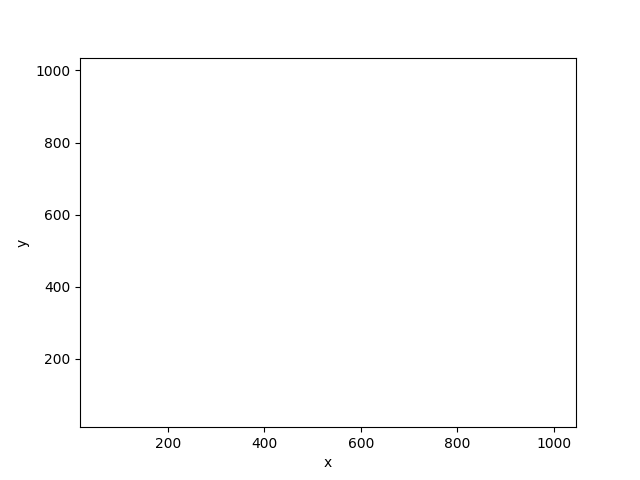

In [14]:
vis.clear()
bool_value,vis=is_intersection_with_visualization(generated_sections)
vis.show_gif(interval=200)

---
W drugim sformułowaniu problemu będziemy poszukiwać wszystkich przecięć odcinków w zadanym zbiorze odcinków. Korzystam z tych samych struktur zdarzeń i stanu co w pierwszym podejściu - ```SortedSet```, ale tym razem przy wykryciu zdarzenia polegającego na przecięciu odcinków, dodaję je do struktury zdarzeń.

<span style="color:red">Ćw.</span> Uzupełnij funkcję ```find_intersections```.

In [15]:
class SweepLineSolver:
    def __init__(self, sections):
        self.raw_sections = sections
        self.n = len(sections)
        
        self.state = SortedSet()      
        self.events = SortedSet()     
        
        self.section_objects = []
        self.checked_pairs = set()   
        self.intersections = []       

    def _initialize(self):
        """Tworzy obiekty Section i wypełnia kolejkę zdarzeń początkowymi punktami."""
        if self.n == 0:
            return

        for i in range(self.n):
            coords = self.raw_sections[i]
            p1 = Point(coords[0][0], coords[0][1])
            p2 = Point(coords[1][0], coords[1][1])
            sec = Section(p1, p2)
            
            self.section_objects.append(sec)
            
            self.events.add((p1, 'l', i))
            self.events.add((p2, 'r', i))

    def _check_pair(self, s1_idx, s2_idx):
        """Sprawdza przecięcie dwóch odcinków i dodaje zdarzenie do kolejki, jeśli znaleziono."""
        sec1 = self.section_objects[s1_idx]
        sec2 = self.section_objects[s2_idx]
        intersection_point = intersects(sec1, sec2)

        if intersection_point is not None:
            self.intersections.append((intersection_point, s1_idx + 1, s2_idx + 1))
            
            p_int = Point(intersection_point[0], intersection_point[1])
            self.events.add((p_int, 'i', s1_idx, s2_idx))

    def _handle_event(self, event):
        """Dyspozytor zdarzeń, wywołujący odpowiednią logikę w zależności od typu."""
        event_point = event[0]
        event_type = event[1]
        
        new_neighbours = []
        
        if event_type == 'l':
            idx = event[2]
            Section.update_sweep(event_point.x) 
            entry = (self.section_objects[idx], idx)
            self.state.add(entry)
            current_pos = self.state.index(entry)

            if current_pos > 0:
                neighbor_idx = self.state[current_pos - 1][1]
                pair = tuple(sorted((neighbor_idx, idx)))
                if pair not in self.checked_pairs:
                    self.checked_pairs.add(pair)
                    new_neighbours.append(pair)
            
            if current_pos < len(self.state) - 1:
                neighbor_idx = self.state[current_pos + 1][1]
                pair = tuple(sorted((neighbor_idx, idx)))
                if pair not in self.checked_pairs:
                    self.checked_pairs.add(pair)
                    new_neighbours.append(pair)

        elif event_type == 'r':
            idx = event[2]
            Section.update_sweep(event_point.x)
            entry = (self.section_objects[idx], idx)
            
            try:
                current_pos = self.state.index(entry)
            except ValueError:
                return 

            if 0 < current_pos < len(self.state) - 1:
                neighbor_below = self.state[current_pos - 1][1]
                neighbor_above = self.state[current_pos + 1][1]
                pair = tuple(sorted((neighbor_below, neighbor_above)))
                
                if pair not in self.checked_pairs:
                    self.checked_pairs.add(pair)
                    new_neighbours.append(pair)

            del self.state[current_pos]

        else:
            idx1, idx2 = event[2], event[3]
            entry1 = (self.section_objects[idx1], idx1)
            entry2 = (self.section_objects[idx2], idx2)
            
            if entry1 not in self.state or entry2 not in self.state:
                return

            pos1 = self.state.index(entry1)
            pos2 = self.state.index(entry2)

            for pos, current_idx in [(pos1, idx1), (pos2, idx2)]:
                other_idx = idx2 if current_idx == idx1 else idx1
                
                if pos > 0:
                    neighbor_idx = self.state[pos - 1][1]
                    pair = tuple(sorted((neighbor_idx, other_idx)))
                    if pair not in self.checked_pairs:
                        self.checked_pairs.add(pair)
                        new_neighbours.append(pair)
                
                if pos < len(self.state) - 1:
                    neighbor_idx = self.state[pos + 1][1]
                    pair = tuple(sorted((neighbor_idx, other_idx)))
                    if pair not in self.checked_pairs:
                        self.checked_pairs.add(pair)
                        new_neighbours.append(pair)

            if pos1 < pos2:
                del self.state[pos2]
                del self.state[pos1]
            else:
                del self.state[pos1]
                del self.state[pos2]
                
            Section.update_sweep(event_point.x + 1e-8)
            
            self.state.add(entry1)
            self.state.add(entry2)
            
        for s1_idx, s2_idx in new_neighbours:
            self._check_pair(s1_idx, s2_idx)

    def run(self):
        """Główna pętla algorytmu zamiatania."""
        self._initialize()

        while len(self.events) > 0:
            event = self.events.pop(0)
            self._handle_event(event)
            
        return self.intersections

def find_intersections(sections):
    """
    Funkcja znajduje wszystkie przecięcia zadanych odcinków, zwracając jednocześnie 
    kroki wizualizacji. Wrapper dla klasy SweepLineSolver.
    
    :param sections: lista odcinków w postaci krotek ((x1, y1), (x2, y2))
    :return: (lista przecięć [((x,y), id1, id2), ...], obiekt Visualizer)
    """
    solver = SweepLineSolver(sections)
    return solver.run()

Przetestuj działanie funkcji ```find_intersections```.

In [16]:
Test().runtest(3,find_intersections)

Lab 4, task 3:
	Test 1: Passed
	Test 2: Passed
	Test 3: Passed
Result: 3/3
Time: 0.001s


Przedstawiam to samo dla wygenerowanych zbiorów odcinków.

In [17]:
generated_intersections=find_intersections(generated_sections)

52


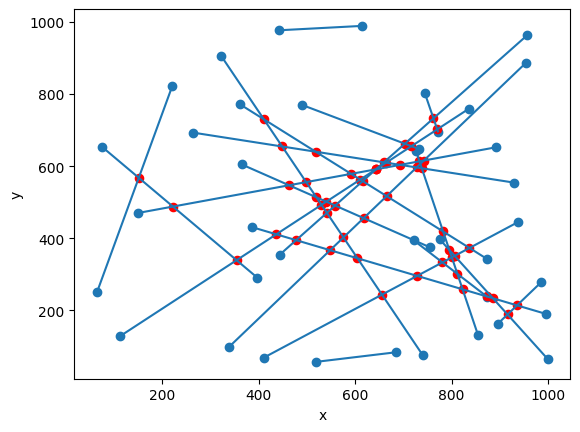

In [18]:
vis.clear()
print(len(generated_intersections))
vis=Visualizer()
vis.add_line_segment(generated_sections)
vis.add_point([generated_sections[i//2][i%2] for i in range(2*len(generated_sections))])
vis.add_point([generated_intersections[i][0] for i in range(len(generated_intersections))],color="red",s=35)
vis.show()

---
<span style="color:red">Ćw.</span> Uzupełnij funkcję ```find_intersections_with_visualization```.

In [19]:
class SweepLineSolver:
    def __init__(self, sections):
        self.raw_sections = sections
        self.n = len(sections)
        
        self.state = SortedSet()  
        self.events = SortedSet() 
        
        self.section_objects = []
        self.checked_pairs = set()
        self.intersections = []
        self.vis = Visualizer()
        
        all_coords = [p for s in sections for p in s]
        if all_coords:
            self.min_y = min(p[1] for p in all_coords)
            self.max_y = max(p[1] for p in all_coords)
        else:
            self.min_y, self.max_y = 0, 0

    def _initialize(self):
        """Inicjalizacja obiektów Section, kolejki zdarzeń i wizualizera."""
        if self.n == 0:
            return
        self.vis.add_line_segment(self.raw_sections)
        all_points = [self.raw_sections[i // 2][i % 2] for i in range(2 * self.n)]
        self.vis.add_point(all_points, color="blue")

        for i in range(self.n):
            coords = self.raw_sections[i]
            p1 = Point(coords[0][0], coords[0][1])
            p2 = Point(coords[1][0], coords[1][1])
            sec = Section(p1, p2)
            
            self.section_objects.append(sec)
            self.events.add((p1, 'l', i))
            self.events.add((p2, 'r', i))

    def _check_pairs(self, pairs_to_check):
        """
        Sprawdza listę par odcinków pod kątem przecięć.
        Obsługuje wizualizację: żółty (sprawdzanie) -> czerwony (przecięcie).
        """
        for s1_idx, s2_idx in pairs_to_check:
            handles = []
            handles.append(self.vis.add_point(self.raw_sections[s1_idx][0], color="yellow", s=25))
            handles.append(self.vis.add_point(self.raw_sections[s1_idx][1], color="yellow", s=25))
            handles.append(self.vis.add_line_segment(self.raw_sections[s1_idx], color="yellow"))
            
            handles.append(self.vis.add_point(self.raw_sections[s2_idx][0], color="yellow", s=25))
            handles.append(self.vis.add_point(self.raw_sections[s2_idx][1], color="yellow", s=25))
            handles.append(self.vis.add_line_segment(self.raw_sections[s2_idx], color="yellow"))

            sec1 = self.section_objects[s1_idx]
            sec2 = self.section_objects[s2_idx]
            intersection_point = intersects(sec1, sec2)

            if intersection_point is not None:
                self.vis.add_point(intersection_point, color="red", s=35)
                self.intersections.append((intersection_point, s1_idx + 1, s2_idx + 1))
                
                p_int = Point(intersection_point[0], intersection_point[1])
                self.events.add((p_int, 'i', s1_idx, s2_idx))

            for handle in handles:
                self.vis.remove_figure(handle)

    def _handle_start(self, event_point, idx):
        """Obsługa początku odcinka ('l')."""
        Section.update_sweep(event_point.x)
        
        entry = (self.section_objects[idx], idx)
        self.state.add(entry)
        
        self.vis.add_point((event_point.x, event_point.y), color="green", s=25)
        self.vis.add_line_segment(self.raw_sections[idx], color="green")
        self.vis.add_point(self.raw_sections[idx][1], color="green", s=25)
        current_pos = self.state.index(entry)
        pairs_to_check = []

        if current_pos > 0:
            neighbor_idx = self.state[current_pos - 1][1]
            pair = tuple(sorted((neighbor_idx, idx)))
            if pair not in self.checked_pairs:
                self.checked_pairs.add(pair)
                pairs_to_check.append(pair)
        
        if current_pos < len(self.state) - 1:
            neighbor_idx = self.state[current_pos + 1][1]
            pair = tuple(sorted((neighbor_idx, idx)))
            if pair not in self.checked_pairs:
                self.checked_pairs.add(pair)
                pairs_to_check.append(pair)
        
        self._check_pairs(pairs_to_check)

    def _handle_end(self, event_point, idx):
        Section.update_sweep(event_point.x)
        
        entry = (self.section_objects[idx], idx)
        try:
            current_pos = self.state.index(entry)
        except ValueError:
            return 
            

        self.vis.add_point((event_point.x, event_point.y), color="brown", s=25)
        self.vis.add_line_segment(self.raw_sections[idx], color="brown")
        self.vis.add_point(self.raw_sections[idx][0], color="brown", s=25)

        pairs_to_check = []
        if 0 < current_pos < len(self.state) - 1:
            neighbor_below = self.state[current_pos - 1][1]
            neighbor_above = self.state[current_pos + 1][1]
            pair = tuple(sorted((neighbor_below, neighbor_above)))
            
            if pair not in self.checked_pairs:
                self.checked_pairs.add(pair)
                pairs_to_check.append(pair)

        del self.state[current_pos]
        self._check_pairs(pairs_to_check)

    def _handle_intersection(self, event_point, idx1, idx2):
        entry1 = (self.section_objects[idx1], idx1)
        entry2 = (self.section_objects[idx2], idx2)
        
        if entry1 not in self.state or entry2 not in self.state:
            return

        pos1 = self.state.index(entry1)
        pos2 = self.state.index(entry2)
        
        pairs_to_check = []
        

        for pos, current_idx in [(pos1, idx1), (pos2, idx2)]:

            if pos > 0:
                neighbor_idx = self.state[pos - 1][1]
                other_idx = idx2 if current_idx == idx1 else idx1
                pair = tuple(sorted((neighbor_idx, other_idx)))
                if pair not in self.checked_pairs:
                    self.checked_pairs.add(pair)
                    pairs_to_check.append(pair)
            
            if pos < len(self.state) - 1:
                neighbor_idx = self.state[pos + 1][1]
                other_idx = idx2 if current_idx == idx1 else idx1
                pair = tuple(sorted((neighbor_idx, other_idx)))
                if pair not in self.checked_pairs:
                    self.checked_pairs.add(pair)
                    pairs_to_check.append(pair)


        if pos1 < pos2:
            del self.state[pos2]
            del self.state[pos1]
        else:
            del self.state[pos1]
            del self.state[pos2]
            

        Section.update_sweep(event_point.x + 1e-8)
        

        self.state.add(entry1)
        self.state.add(entry2)
        
        self._check_pairs(pairs_to_check)

    def run(self):
        if self.n == 0:
            return False, self.vis

        self._initialize()

        while len(self.events) > 0:
            event = self.events.pop(0)
            point = event[0]
            etype = event[1]
            

            broom = self.vis.add_line(((point.x, self.min_y), (point.x, self.max_y)), color="red")
            
            if etype == 'l':
                self._handle_start(point, event[2])
            elif etype == 'r':
                self._handle_end(point, event[2])
            elif etype == 'i': # Intersection
                self._handle_intersection(point, event[2], event[3])
                
            self.vis.remove_figure(broom)
            
        return self.intersections, self.vis



def find_intersections_with_visualization(sections):
    """
    Funkcja znajduje wszystkie przecięcia zadanych odcinków, zwracając jednocześnie 
    kroki wizualizacji. Wrapper dla klasy SweepLineSolver.
    
    :param sections: lista odcinków w postaci krotek ((x1, y1), (x2, y2))
    :return: (lista przecięć [((x,y), id1, id2), ...], obiekt Visualizer)
    """
    solver = SweepLineSolver(sections)
    return solver.run()

Zobaczmy wizualizację kolejnych kroków działania algorytmu znajdowania wszystkich przecięć. Algorytm bada sąsiednie odcinki przecinane przez miotłę, zaznaczając je zgodnie z przyjętą konwencją kolorystyczną.

KeyboardInterrupt: 

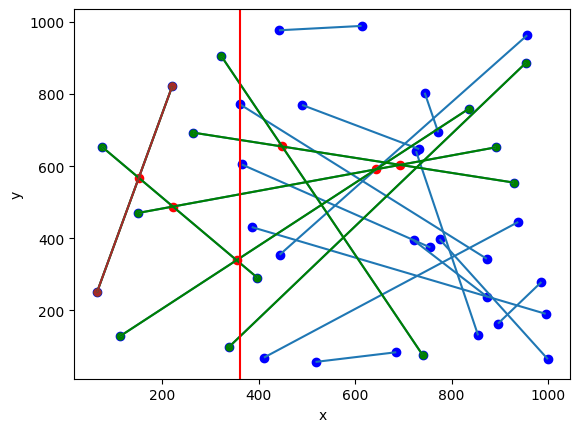

In [20]:
vis.clear()
intersections,vis=find_intersections_with_visualization(generated_sections)
vis.show_gif(interval=50)

### Czy konieczne były zmiany w strukturze zdarzeń. Jeśli tak, to jakie? Czy w przypadku obu algorytmów konieczne są takie same struktury zdarzeń? Odpowiedź uzasadnij. 

### Jak obsługiwane są zdarzenia początku odcinka, końca odcinka i przecięcia odcinków z uwzględnianiem wybranych struktur danych?

### Samemu zaprojektuj test, który uwzględnia taki układ odcinków, przy którym pewne przecięcia będą wykrywane więcej niż jeden raz

### Czy Twój program uwzględnia powyższy przypadek? Jeśli tak, to jak? 

---